# Fig. S26 | Recovery timing

Shows how a 20% Uniform reduction during recovery changes the timing of half recovery.

In [1]:
from pathlib import Path
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = next(p.resolve() for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'management').is_dir())
DATA=ROOT/'outputs'/'MANAGEMENT_2012_2013'/'equal_volume'
OUT=ROOT/'outputs'/'figures'/'FigS26'/'FigS26.png'
OUT.parent.mkdir(parents=True,exist_ok=True)
cells=pd.read_csv(DATA/'recovery_time_cells.csv.gz',dtype={'seed':str})
PI75=1.150349
mpl.rcParams.update({'font.family':'Arial','font.size':10.5,'axes.labelsize':12.5,'axes.titlesize':12.5,'xtick.labelsize':9.5,'ytick.labelsize':10,'axes.linewidth':0.8,'axes.spines.top':True,'axes.spines.right':True})

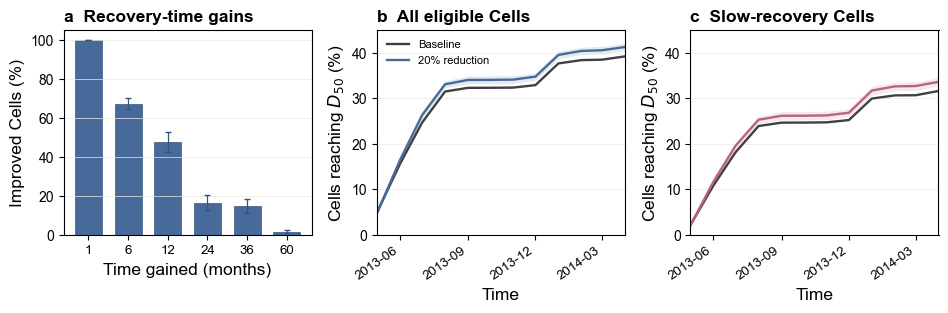

In [2]:
eligible=cells[cells.valid_flag & ~cells.reached_before_intervention]
comparable=eligible[np.isfinite(eligible.delta_T50)]
thresholds=np.array([1,6,12,24,36,60])
curves=[]
for _,group in comparable.groupby('seed'):
    gains=group.loc[group.delta_T50>0,'delta_T50'].to_numpy(float)
    curves.append([np.mean(gains>=threshold) for threshold in thresholds])
curves=np.asarray(curves); mean=100*curves.mean(0); radius=100*PI75*curves.std(0,ddof=0)
fig,axes=plt.subplots(1,3,figsize=(9.6,3.25))
x=np.arange(len(thresholds)); axes[0].bar(x,mean,width=0.68,color='#486A9A',edgecolor='#365579',lw=0.5)
axes[0].errorbar(x,mean,yerr=radius,fmt='none',color='#365579',capsize=2,lw=0.9)
axes[0].set_xticks(x,thresholds); axes[0].set_ylim(0,105); axes[0].set(xlabel='Time gained (months)',ylabel='Improved Cells (%)',title='a  Recovery-time gains')

dates=pd.date_range('2013-05-01','2014-04-01',freq='MS')
def cumulative_curves(frame):
    baseline=pd.to_datetime(frame.drop_duplicates('cell_id').T50_base_month,errors='coerce')
    base=np.array([(baseline<=date).mean() for date in dates])
    managed=[]
    for _,group in frame.groupby('seed'):
        values=pd.to_datetime(group.T50_management_month,errors='coerce')
        managed.append([(values<=date).mean() for date in dates])
    managed=np.asarray(managed); mean=managed.mean(0); radius=PI75*managed.std(0,ddof=0)
    return base,mean,mean-radius,mean+radius

for ax,frame,title,color in [(axes[1],eligible,'b  All eligible Cells','#486A9A'),(axes[2],eligible[eligible.response_class.eq('Slow recovery')],'c  Slow-recovery Cells','#B8647C')]:
    base,mean,low,high=cumulative_curves(frame)
    ax.plot(dates,100*base,color='0.25',lw=1.7,label='Baseline')
    ax.fill_between(dates,100*low,100*high,color=color,alpha=0.14,lw=0)
    ax.plot(dates,100*mean,color=color,lw=1.7,label='20% reduction')
    ax.set(xlabel='Time',ylabel=r'Cells reaching $D_{50}$ (%)',title=title,ylim=(0,45),xlim=(dates.min(),dates.max()))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3)); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.get_xticklabels(),rotation=35,ha='right')
axes[1].legend(frameon=False,fontsize=8,loc='upper left')
for ax in axes:
    ax.title.set_fontweight('bold'); ax.title.set_ha('left'); ax.title.set_position((0,1)); ax.grid(axis='y',color='#ECE9E4',lw=0.5)
fig.tight_layout(w_pad=1.0); fig.savefig(OUT,dpi=600,bbox_inches='tight',facecolor='white'); plt.show()